# Section 1: Import Libraries and Load Dataset

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset
df = pd.read_csv("/Users/manvi/Downloads/Crop Production data.csv")

# Section 2: Introduction

## Background

Agriculture plays a crucial role in India's economy and food supply. However, crop production varies across states, seasons, crop types, and cultivated areas, making accurate production forecasting essential for effective planning. Predictive analytics can analyze historical agricultural data to estimate future production and support data-driven decision-making.

## Business Problem

Uncertainty in crop production can lead to inefficient procurement, storage, transportation, and resource allocation. Developing an accurate prediction model can help governments and agribusinesses improve planning and optimize supply chain decisions.

## Objective

The objective of this project is to develop a machine learning model to predict crop production using historical agricultural data and identify the key factors influencing agricultural output.

# Section 3: Dataset Understanding
The dataset used in this project is the **Crop Production in India** dataset obtained from Kaggle. It contains historical records of agricultural production across different states and districts of India.

In [3]:
# Display dataset dimensions
df.shape

# Display dataset information
df.info()

# Display summary statistics
df.describe(include='all')

# Display the first five rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Kharif,Arecanut,1254.0,2000.0
1,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Kharif,Rice,102.0,321.0
3,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Whole Year,Banana,176.0,641.0
4,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Whole Year,Cashewnut,720.0,165.0


# Section 4: Data Preprocessing
The dataset was preprocessed by checking for missing values, duplicate records, and data types. Missing values in the target variable (`Production`) were removed, and boxplots were used to examine outliers. Outliers were observed in the **Area** and **Production** variables but were retained as they represent genuine variations in agricultural data. Additionally, an `Area_Category` feature was created through feature engineering, and categorical variables were encoded to prepare the data for predictive modelling.

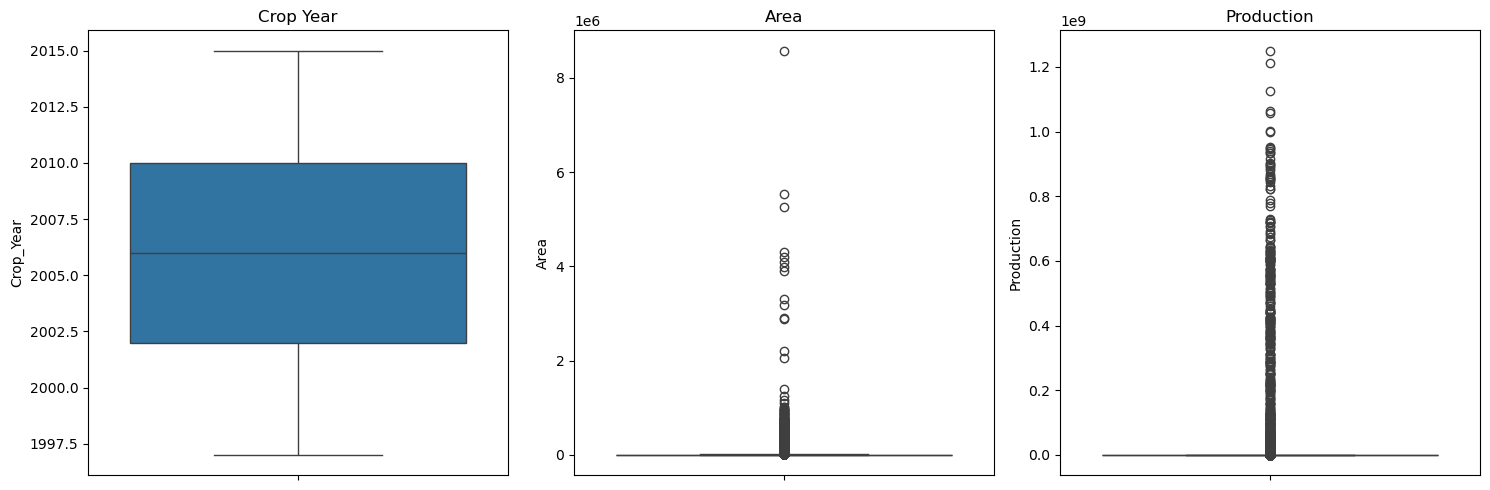

In [4]:
# Check for missing values
df.isnull().sum()

# Check for duplicate rows
df.duplicated().sum()

# Verify data types
df.dtypes

# Remove rows with missing target values
df = df.dropna(subset=["Production"])

# Verify missing values after cleaning
df.isnull().sum()


# Visualize outliers in numerical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df["Crop_Year"], ax=axes[0])
axes[0].set_title("Crop Year")

sns.boxplot(y=df["Area"], ax=axes[1])
axes[1].set_title("Area")

sns.boxplot(y=df["Production"], ax=axes[2])
axes[2].set_title("Production")

plt.tight_layout()
plt.show()

# Create area categories
df["Area_Category"] = pd.qcut(
    df["Area"],
    q=4,
    labels=["Small", "Medium", "Large", "Very Large"],
    duplicates="drop"
)


# Section 5: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to understand the distribution of agricultural production, identify patterns and relationships among variables, and derive meaningful business insights. The following visualizations highlight key trends in crop production across different states, seasons, years, and cultivated areas, providing a strong foundation for predictive modelling.

## 5.1 Distribution of Crop Production
**Interpretation:**  
Average production generally increases with larger cultivated area categories, indicating that farm size has a positive influence on agricultural output. This suggests that cultivated area is an important factor when predicting crop production.

**Business Insight:**  
The uneven distribution of crop production suggests that agricultural output is concentrated in a limited number of crops and regions. This information can help policymakers and agribusinesses prioritize investments, improve procurement planning, and allocate resources more effectively.

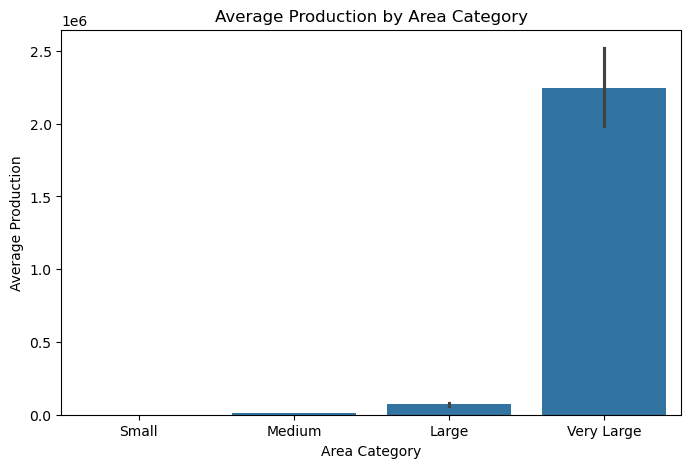

In [5]:
# Compare average production across area categories
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Area_Category",
    y="Production",
    estimator="mean"
)

plt.title("Average Production by Area Category")
plt.xlabel("Area Category")
plt.ylabel("Average Production")

plt.show()

## 5.2 Top 10 Crops by Total Production
**Interpretation:**  
A small number of crops contribute to the majority of agricultural production. These crops can be prioritized for procurement, storage, and supply chain investments to maximize operational efficiency.

**Business Insight:**  
High-producing crops should be prioritized for procurement, storage, transportation, and supply chain planning. Focusing investments on these crops can improve resource utilization and support better agricultural decision-making.

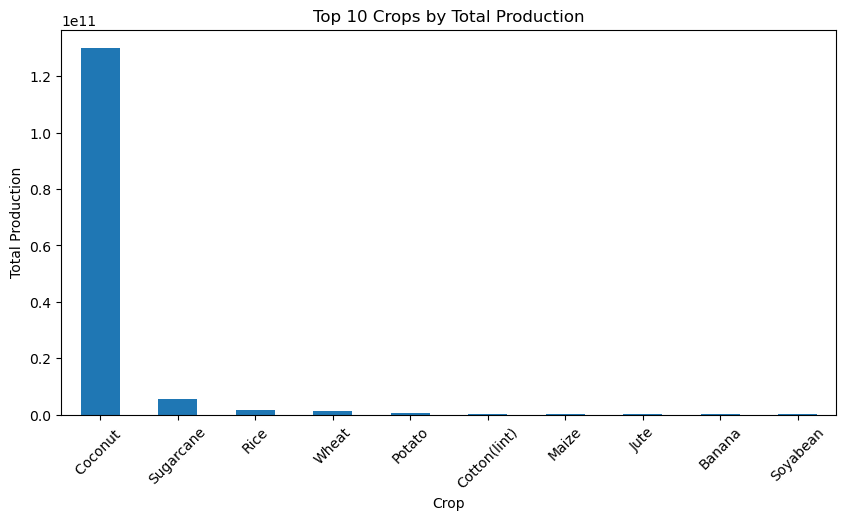

In [6]:
# Identify the top 10 crops by production
top_crops = df.groupby("Crop")["Production"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_crops.plot(kind="bar")
plt.title("Top 10 Crops by Total Production")
plt.xlabel("Crop")
plt.ylabel("Total Production")
plt.xticks(rotation=45)
plt.show()

## 5.3 Top 10 States by Total Production
**Interpretation:**  
Agricultural production is concentrated in a few states. These regions can be prioritized for infrastructure development, procurement planning, and policy interventions.

**Business Insight:**  
States with consistently high production can be prioritized for procurement centers, warehouse infrastructure, and transportation networks. Identifying these high-producing regions also helps governments and agribusinesses optimize resource allocation and strengthen agricultural supply chains.

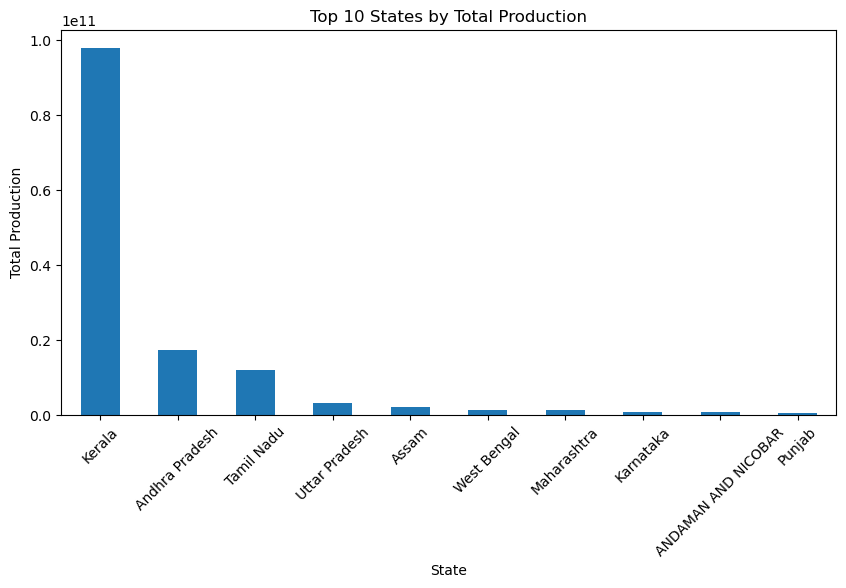

In [7]:
# Identify the top 10 producing states
top_states = df.groupby("State_Name")["Production"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind="bar")
plt.title("Top 10 States by Total Production")
plt.xlabel("State")
plt.ylabel("Total Production")
plt.xticks(rotation=45)
plt.show()

## 5.4 Production by Season
**Interpretation:**  
Seasonal variations have a noticeable impact on agricultural production. Understanding these patterns helps optimize harvesting schedules, inventory planning, and resource allocation.

**Business Insight:**  
Understanding seasonal production patterns helps governments and agribusinesses plan procurement, storage, transportation, and labor requirements more efficiently. Resources can be allocated in advance for high-production seasons to minimize post-harvest losses and improve supply chain efficiency.

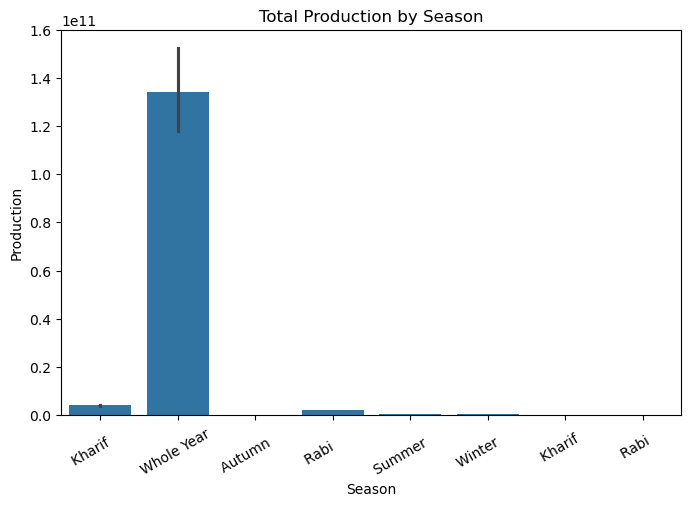

In [8]:
# Compare production across seasons
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Production", estimator=sum)
plt.title("Total Production by Season")
plt.xlabel("Season")
plt.ylabel("Production")
plt.xticks(rotation=30)
plt.show()

## 5.5 Area vs Production
**Interpretation:**  
Larger cultivated areas generally correspond to higher production, indicating a positive relationship between land area and agricultural output. However, the wide spread of points suggests that other factors also influence production.

**Business Insight:**  
The positive association between cultivated area and production suggests that land availability is an important factor in determining agricultural output. However, the variation among observations indicates that improving farming practices, irrigation, seed quality, and technology can also enhance production without solely relying on expanding cultivated land.

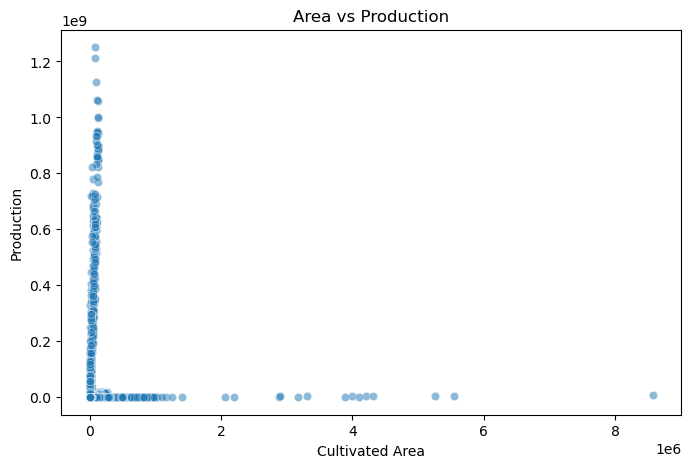

In [9]:
# Examine the relationship between area and production
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Area", y="Production", alpha=0.5)
plt.title("Area vs Production")
plt.xlabel("Cultivated Area")
plt.ylabel("Production")
plt.show()

## 5.6 Correlation Heatmap
**Interpretation:**  
The correlation matrix highlights the strength of relationships among numerical variables. A strong correlation between Area and Production would indicate that cultivated land is an important predictor of crop output.

**Business Insight:**  
The strong relationship between **Area** and **Production** indicates that cultivated land is an important predictor of agricultural output. This insight supports its inclusion in predictive models and can help policymakers and agribusinesses make informed decisions regarding land utilization and production planning.

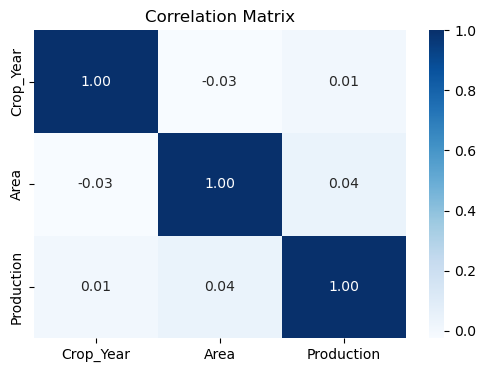

In [10]:
# Display correlations among numerical variables
plt.figure(figsize=(6,4))
sns.heatmap(df[["Crop_Year","Area","Production"]].corr(),
            annot=True,
            cmap="Blues",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

## 5.7 Production Trend Over Years
**Interpretation:**  
The trend illustrates how agricultural production has changed over time. Long-term growth or decline can help policymakers and businesses identify changing production patterns and support strategic planning.

**Business Insight:**  
Understanding long-term production trends enables governments and agribusinesses to forecast future demand, plan storage and procurement capacities, and develop strategies to improve agricultural productivity. Trend analysis also supports better policy formulation and long-term investment decisions.

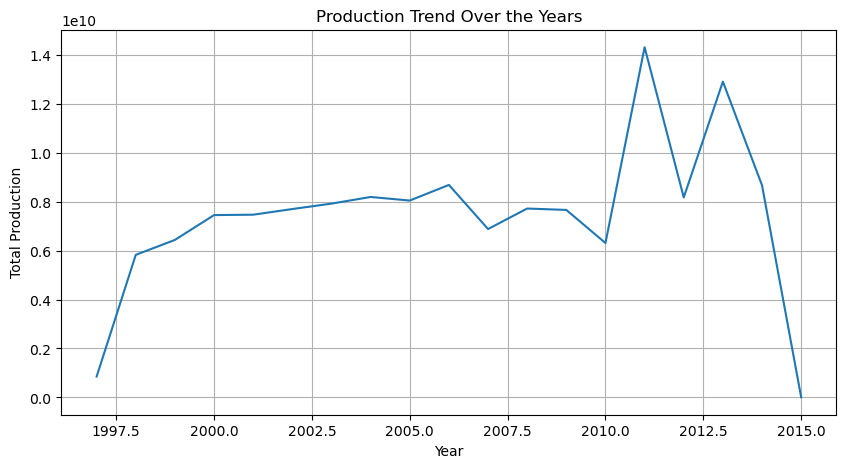

In [11]:
# Analyze production trends over time
yearly = df.groupby("Crop_Year")["Production"].sum()

plt.figure(figsize=(10,5))
yearly.plot()
plt.title("Production Trend Over the Years")
plt.xlabel("Year")
plt.ylabel("Total Production")
plt.grid(True)
plt.show()

# Section 6: Model Building

The dataset was divided into training and testing sets to evaluate the predictive performance of different machine learning models. Three regression models—Linear Regression, Decision Tree Regressor, and Random Forest Regressor—were developed and compared to identify the most suitable model for predicting crop production.

In [12]:
# Encode categorical variables
label_encoder = LabelEncoder()

categorical_cols = [
    "State_Name",
    "District_Name",
    "Season",
    "Crop",
    "Area_Category"
]

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

## 6.1 Train-Test Split
The dataset was split into **80% training data** and **20% testing data**. The training set was used to build the models, while the testing set was used to evaluate their predictive performance on unseen data.

In [13]:
# Define features and target variable
X = df.drop("Production", axis=1)
y = df["Production"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 6.2 Models Used
- **Linear Regression:** Serves as a baseline model by assuming a linear relationship between the features and crop production.
- **Decision Tree Regressor:** Captures non-linear relationships and is easy to interpret.
- **Random Forest Regressor:** Combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [14]:
# Initialize regression models
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)

## 6.3 Train the Models

In [15]:
# Train Linear Regression
lr.fit(X_train, y_train)

# Train Decision Tree
dt.fit(X_train, y_train)

# Train Random Forest
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## 6.4 Generate Predictions

In [16]:
# Generate predictions
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

## 6.5 Evaluation Metrics
- **Mean Absolute Error (MAE):** Measures the average prediction error.
- **Mean Squared Error (MSE):** Penalizes larger prediction errors more heavily.
- **R² Score:** Indicates how well the model explains the variation in crop production. A value closer to **1** represents better predictive performance.

In [17]:
# Create a function to evaluate model performance
def evaluate_model(y_true, y_pred):
    return [
        mean_absolute_error(y_true, y_pred),
        mean_squared_error(y_true, y_pred),
        r2_score(y_true, y_pred)
    ]

# Compare model performance
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [
        evaluate_model(y_test, lr_pred)[0],
        evaluate_model(y_test, dt_pred)[0],
        evaluate_model(y_test, rf_pred)[0]
    ],
    "MSE": [
        evaluate_model(y_test, lr_pred)[1],
        evaluate_model(y_test, dt_pred)[1],
        evaluate_model(y_test, rf_pred)[1]
    ],
    "R² Score": [
        evaluate_model(y_test, lr_pred)[2],
        evaluate_model(y_test, dt_pred)[2],
        evaluate_model(y_test, rf_pred)[2]
    ]
})

results

,Model,MAE,MSE,R² Score
0,Linear Regression,1.714281e+06,3.994226e+14,0.007246
1,Decision Tree,1.487408e+05,5.792733e+13,0.856023
2,Random Forest,1.429219e+05,3.034107e+13,0.924588


# Section 7: Results

The performance of the three regression models was compared using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score. The model with the highest R² Score and the lowest error values was selected as the best-performing model for predicting crop production.

## 7.1 Model Comparison
**Interpretation:**  
The comparison table summarizes the performance of all three regression models. Lower MAE and MSE values indicate smaller prediction errors, while a higher R² Score represents better predictive accuracy.

In [19]:
# Display model comparison
results

,Model,MAE,MSE,R² Score
0,Linear Regression,1.714281e+06,3.994226e+14,0.007246
1,Decision Tree,1.487408e+05,5.792733e+13,0.856023
2,Random Forest,1.429219e+05,3.034107e+13,0.924588


## 7.2 Best Model
**Interpretation:**  
The model with the highest R² Score was selected as the best-performing model, as it explains the greatest proportion of variation in crop production while maintaining lower prediction errors.

In [20]:
# Identify the best-performing model
best_model = results.loc[results["R² Score"].idxmax()]

print(best_model)

Model               Random Forest
MAE                 142921.910144
MSE         30341070847788.015625
R² Score                 0.924588
Name: 2, dtype: object


## 7.3 Feature Importance (Random Forest)
**Interpretation:**  
The feature importance chart identifies the variables that contribute the most to predicting crop production. Features with higher importance have a greater influence on the model's predictions.
**Key Finding:**  
The model indicates that the most influential features are those related to cultivated area and crop characteristics. This suggests that these variables play a significant role in determining agricultural production and should be considered when making production forecasts and planning agricultural resources.

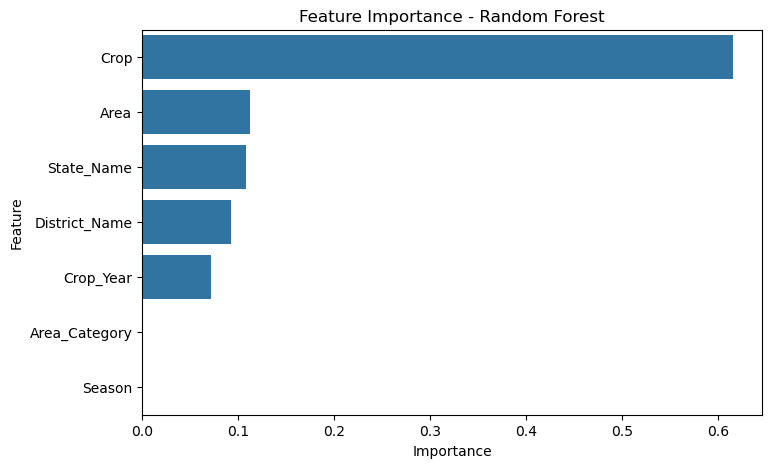

In [23]:
# Plot feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 7.4 Actual vs Predicted Values
**Interpretation:**  
The scatter plot compares the actual and predicted production values. Points closer to the diagonal reference line indicate more accurate predictions, demonstrating the model's effectiveness in estimating crop production.

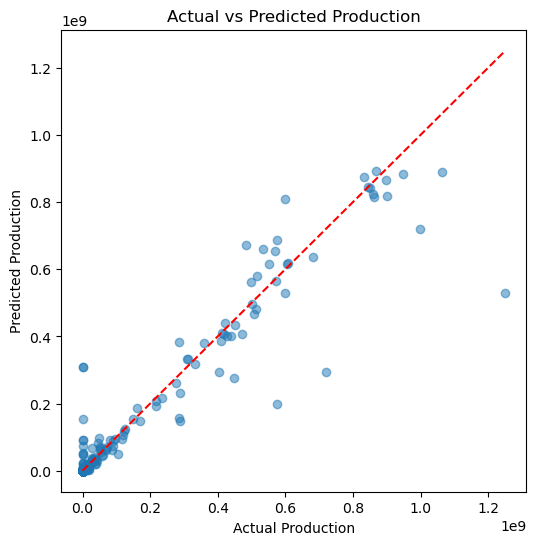

In [21]:
# Compare actual and predicted production
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted Production")

plt.show()

# Section 8: Business Insights & Recommendations

The analysis provides several actionable insights that can support agricultural planning, resource allocation, and production forecasting.

### Key Business Insights

1. **Cultivated area is one of the strongest drivers of crop production.** Expanding cultivated land or improving land utilization can significantly increase agricultural output.

2. **Agricultural production is concentrated in a few states.** These regions should be prioritized for procurement centers, warehouse development, and transportation infrastructure to improve supply chain efficiency.

3. **Seasonal variations have a significant impact on production.** Understanding seasonal trends enables better planning of labor, storage, and distribution activities during peak production periods.

4. **Crop production varies considerably across crops and regions.** This indicates that production planning should consider regional characteristics rather than adopting a uniform strategy across all locations.

5. **The machine learning model demonstrates that production can be predicted using historical agricultural data.** Predictive analytics can support informed decision-making by helping stakeholders estimate future production and allocate resources more effectively.

### Recommendations

- Prioritize investments in high-producing states to strengthen procurement and storage infrastructure.
- Encourage efficient land utilization and modern farming practices to improve crop productivity.
- Develop season-specific production and logistics plans to reduce post-harvest losses.
- Use predictive models to estimate future crop production and support strategic planning.
- Continuously update the dataset with recent agricultural records to improve prediction accuracy over time.

# Section 8: Conclusion

This study analyzed historical agricultural data to predict crop production using machine learning techniques. After preprocessing and exploratory data analysis, three regression models were developed and evaluated. The best-performing model demonstrated that factors such as cultivated area, crop type, season, and location play an important role in predicting agricultural production. The findings highlight how predictive analytics can support data-driven decision-making, helping governments and agribusinesses improve production planning, resource allocation, and supply chain management.

# Section 9: Future Scope

- Incorporate additional variables such as rainfall, temperature, soil quality, and fertilizer usage to improve prediction accuracy.
- Explore advanced machine learning models such as XGBoost and Gradient Boosting for better performance.
- Develop an interactive dashboard using Power BI or Tableau to visualize production trends and model predictions for decision-makers.